In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import random

# Data

In [74]:
def get_swiss_roll(samples=512):
    t = 1.5 * 3.14159 * (1 + 2 * torch.rand(samples, 1))
    x = t * torch.cos(t)
    y = t * torch.sin(t)
    data = torch.cat([x, y], dim=1)
    data += 0.5 * torch.randn_like(data)
    return data


In [75]:
def get_coeficients(t):
    alpha = torch.cos(3.14159 * t / 2)
    beta = torch.sin(3.14159 * t / 2)
    return alpha, beta

# Model

In [76]:
class VDiffusion(nn.Module):
    def __init__(self, network):
        """
        network: The neural network (e.g., a UNet or MLP) that predicts the original sample.
        """
        super().__init__()
        self.network = network

    def get_coefficients(self, t):
        """
        Implements the v-diffusion coefficients on a circle (Page 6).
        Ensures constant power through the whole process.
        """
        # alpha = cos(pi * t / 2), beta = sin(pi * t / 2) [cite: 33]
        alpha = torch.cos(3.14159 * t / 2)
        beta = torch.sin(3.14159 * t / 2)
        return alpha, beta

    def forward(self, x0):
        """
        Training Process: Forward Diffusion (Page 7)
        """
        # 1. Sample a random time t for each item in the batch 
        t = torch.rand((x0.shape[0], 1), device=x0.device)
        
        # 2. Get circle coefficients [cite: 34]
        alpha, beta = self.get_coefficients(t)
        
        # 3. Add noise to the real sample [cite: 34]
        noise = torch.randn_like(x0) 
        latent = alpha * x0 + beta * noise 
        
        # 4. Model predicts the original point from the target distribution [cite: 45]
        # We pass 't' so the network knows the noise level.
        predicted_x0 = self.network(latent, t)
        
        return predicted_x0, x0

    @torch.no_grad()
    def sample(self, shape, steps=20, device='cpu'):
        """
        Inference Process: Backward Diffusion (Page 8, 9)
        Transforms source distribution (noise) into target distribution.
        """
        # Start from pure noise (source distribution) [cite: 51, 52]
        x = torch.randn(shape, device=device)
        
        # Divide the inference process into many tiny steps [cite: 13, 16]
        dt = 1.0 / steps
        
        for i in range(steps):
            # t goes from 1 (full noise) down to 0 (clean sample)
            t_val = 1.0 - (i * dt)
            t = torch.full((shape[0], 1), t_val, device=device)
            
            # 1. Predict the final x0 (Predicted Sample) [cite: 42, 49]
            pred_x0 = self.network(x, t)
            
            # 2. Get current coefficients
            alpha, beta = self.get_coefficients(t)
            
            # 3. In v-diffusion, we use the prediction to move along the 
            # SDE Trajectory/Probability Flow (Page 5).
            # This is a simplified Euler step for the reverse trajectory:
            # We estimate the noise direction: noise_est = (x - alpha*pred_x0) / beta
            noise_est = (x - alpha * pred_x0) / beta
            
            # Move to the next t
            t_next_val = max(0, t_val - dt)
            t_next = torch.full((shape[0], 1), t_next_val, device=device)
            alpha_next, beta_next = self.get_coefficients(t_next)
            
            # Combine predicted x0 and estimated noise for the next step
            x = alpha_next * pred_x0 + beta_next * noise_est
            
        return x

In [77]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),  # 2 coords + 1 for t
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))

# Training

In [78]:
BATCH_SIZE = 512
EPOCHS = 5000
LR = 1e-3

In [79]:
inner_network = SimpleNet()
model = VDiffusion(inner_network)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [80]:
def train_step(real_samples):
    model.train() # Set to training mode
    optimizer.zero_grad()
    
    # Forward pass: gets predicted x0 and original x0
    pred, target = model(real_samples)
    
    # Loss function is MSE [cite: 10, 46]
    loss = F.mse_loss(pred, target)
    
    loss.backward()
    optimizer.step()
    return loss.item()

In [82]:
for epoch in range(EPOCHS):
    real_samples = get_swiss_roll(BATCH_SIZE)
    loss = train_step(real_samples)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 46.375237
Epoch 500, Loss: 7.081692
Epoch 1000, Loss: 5.513713
Epoch 1500, Loss: 5.460025
Epoch 2000, Loss: 6.929467
Epoch 2500, Loss: 5.545825
Epoch 3000, Loss: 5.382793
Epoch 3500, Loss: 5.768381
Epoch 4000, Loss: 5.709072
Epoch 4500, Loss: 6.285685


# Inference

In [86]:
STEPS = 100
TEST_SAMPLES = 3000

In [87]:
generated_points = model.sample((TEST_SAMPLES, 2), steps=STEPS)

# Results

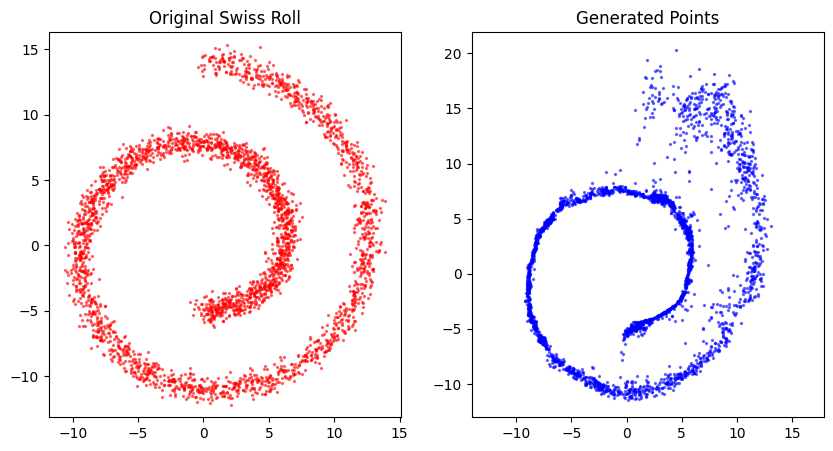

In [88]:
swiss_roll_points = get_swiss_roll(TEST_SAMPLES)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(swiss_roll_points[:, 0], swiss_roll_points[:, 1], s=2, c='red', alpha=0.5)
plt.title("Original Swiss Roll")
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.scatter(generated_points[:, 0], generated_points[:, 1], s=2, c='blue', alpha=0.5)
plt.title("Generated Points")
plt.axis('equal')
plt.show()